In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip -q install lightgbm xgboost neuralforecast statsforecast utilsforecast scikit-learn --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os, glob, warnings
warnings.filterwarnings('ignore')

# ---- EDIT THIS if different: same BASE_DIR you used in Notebook 1 ----
BASE_DIR = '/content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset'
# ------------------------------------------------------------------

def find_file(base_dir, filename):
    matches = glob.glob(os.path.join(base_dir, '**', filename), recursive=True)
    return matches[0] if matches else None

OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')   # written by Notebook 1
FIG_DIR    = os.path.join(BASE_DIR, 'figures')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

merged_path = find_file(OUTPUT_DIR, 'dengue_weather_weekly_merged.csv')
print('FOUND' if merged_path else 'MISSING', 'dengue_weather_weekly_merged.csv', merged_path or '')
assert merged_path, 'Could not find Notebook 1 output. Run Notebook 1 first, or check OUTPUT_DIR.'


FOUND dengue_weather_weekly_merged.csv /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/dengue_weather_weekly_merged.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 300
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv(merged_path, parse_dates=['week_start'])
df = df.sort_values('week_start').reset_index(drop=True)
print(df.shape)
df.head()


(156, 11)


,year,week,week_num,dengue_cases,week_start,avg_temp,max_temp,avg_humidity,total_rain,avg_wind,avg_cloud
0,2023,W01,1,105,2023-01-02,16.905655,25.8,83.145833,0.0,13.430208,12.727679
1,2023,W02,2,56,2023-01-09,18.255952,27.5,78.358631,0.4,10.272768,9.791667
2,2023,W03,3,51,2023-01-16,17.161310,27.0,74.822917,0.1,11.238244,8.839286
3,2023,W04,4,26,2023-01-23,20.358036,28.4,78.227679,0.0,11.679315,6.046131
4,2023,W05,5,30,2023-01-30,20.445089,29.6,76.255952,0.0,12.872619,20.915179


## 1. Feature engineering

- **Lag features** of dengue cases (own-history signal)
- **Rolling weather windows** (4-week mean rain/temp/humidity — mosquito breeding responds to recent weather, not just the current week)
- **Seasonal encoding** (sin/cos of week-of-year — smoother than a raw week number for tree/NN models)
- **Eid holiday-travel feature** — distance in days to the nearest Eid-ul-Fitr / Eid-ul-Adha (mass travel around these dates is a documented driver of regional case-mixing in the Bangladesh dengue literature)
- **Outbreak-year flag** for 2023 (the extreme outlier year identified in Notebook 1's EDA)


In [5]:
# Confirmed Eid dates (Bangladesh, moon-sighting can shift by +/-1 day; fine at weekly resolution)
eid_dates = pd.to_datetime([
    '2023-04-22', '2023-06-29',   # Eid-ul-Fitr, Eid-ul-Adha 2023
    '2024-04-11', '2024-06-17',   # 2024
    '2025-03-31', '2025-06-07',   # 2025
])

def days_to_nearest_eid(date):
    return int(np.min(np.abs((eid_dates - date).days)))

df['days_to_nearest_eid'] = df['week_start'].apply(days_to_nearest_eid)
df['is_eid_window'] = (df['days_to_nearest_eid'] <= 10).astype(int)   # +/-10 days around Eid

df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)
df['is_outbreak_year_2023'] = (df['year'] == 2023).astype(int)

for lag in [1, 2, 4, 8, 12]:
    df[f'cases_lag{lag}'] = df['dengue_cases'].shift(lag)

for win in [4]:
    df[f'rain_roll{win}'] = df['total_rain'].rolling(win).mean()
    df[f'temp_roll{win}'] = df['avg_temp'].rolling(win).mean()
    df[f'humidity_roll{win}'] = df['avg_humidity'].rolling(win).mean()

df_model = df.dropna().reset_index(drop=True)
print('Rows available after lag/rolling warm-up:', df_model.shape)
df_model.tail()


Rows available after lag/rolling warm-up: (144, 24)


,year,week,week_num,dengue_cases,week_start,avg_temp,max_temp,avg_humidity,total_rain,avg_wind,avg_cloud,days_to_nearest_eid,is_eid_window,week_sin,week_cos,is_outbreak_year_2023,cases_lag1,cases_lag2,cases_lag4,cases_lag8,cases_lag12,rain_roll4,temp_roll4,humidity_roll4
139,2025,W48,48,6510,2025-11-24,21.780952,30.0,75.002976,0.0,10.025446,15.822917,170,0,-4.647232e-01,0.885456,0,6835.0,6216.0,5293.0,3196.0,2706.0,19.225,23.730394,76.002976
140,2025,W49,49,5628,2025-12-01,20.634970,28.2,75.877976,0.0,11.626637,36.385417,177,0,-3.546049e-01,0.935016,0,6510.0,6835.0,5398.0,4115.0,2923.0,0.025,22.288244,74.627976
141,2025,W50,50,4280,2025-12-08,20.117708,29.0,74.781250,0.0,9.784375,30.986607,184,0,-2.393157e-01,0.970942,0,5628.0,6510.0,6216.0,3656.0,3375.0,0.000,21.432775,74.651786
142,2025,W51,51,3552,2025-12-15,20.174554,28.9,77.288690,0.6,10.361458,17.552083,191,0,-1.205367e-01,0.992709,0,4280.0,5628.0,6835.0,4741.0,685.0,0.150,20.677046,75.737723
143,2025,W52,52,2777,2025-12-22,17.764137,26.6,83.071429,0.0,10.824107,35.630952,198,0,6.432491e-16,1.000000,0,3552.0,4280.0,6510.0,5293.0,3196.0,0.150,19.672842,77.754836


## 2. Train / holdout split (time-based)

With ~150 usable weeks, we hold out the **last 16 weeks** as the test set (roughly one full monsoon-to-post-monsoon cycle) and train on everything before it. This is a single holdout rather than k-fold, because shuffling time series folds would leak future information — standard practice for small time series.

In [6]:
HOLDOUT_WEEKS = 16
HORIZONS = [1, 2, 4, 8]

train_df = df_model.iloc[:-HOLDOUT_WEEKS].copy()
test_df  = df_model.iloc[-HOLDOUT_WEEKS:].copy()

print('Train weeks:', len(train_df), train_df['week_start'].min().date(), '->', train_df['week_start'].max().date())
print('Test weeks: ', len(test_df),  test_df['week_start'].min().date(),  '->', test_df['week_start'].max().date())


Train weeks: 128 2023-03-27 -> 2025-09-01
Test weeks:  16 2025-09-08 -> 2025-12-22


## 3. Baselines: naive & seasonal-naive

In [7]:
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat, eps=1.0): return np.mean(np.abs(y - yhat) / np.maximum(y, eps)) * 100  # eps avoids div-by-zero

results = []  # will collect {model, horizon, mae, rmse, mape}

for h in HORIZONS:
    y_true = test_df['dengue_cases'].values
    # naive: repeat last known value
    y_naive = np.full_like(y_true, fill_value=train_df['dengue_cases'].iloc[-1], dtype=float)
    # seasonal-naive: same week last year, falls back to naive if unavailable
    y_seasnaive = test_df[f'cases_lag{h}'].values if h in [1,2,4,8] else y_naive

    results.append({'model': 'Naive (last value)', 'horizon': h,
                     'mae': mae(y_true, y_naive), 'rmse': rmse(y_true, y_naive), 'mape': mape(y_true, y_naive)})
    results.append({'model': f'Persistence (lag-{h})', 'horizon': h,
                     'mae': mae(y_true, y_seasnaive), 'rmse': rmse(y_true, y_seasnaive), 'mape': mape(y_true, y_seasnaive)})

pd.DataFrame(results)


,model,horizon,mae,rmse,mape
0,Naive (last value),1,1870.3750,2255.037472,51.868009
1,Persistence (lag-1),1,905.3125,1151.747504,42.813113
2,Naive (last value),2,1870.3750,2255.037472,51.868009
3,Persistence (lag-2),2,1262.4375,1528.287379,47.033740
4,Naive (last value),4,1870.3750,2255.037472,51.868009
5,Persistence (lag-4),4,1735.6250,2083.340347,53.439512
6,Naive (last value),8,1870.3750,2255.037472,51.868009
7,Persistence (lag-8),8,2255.8750,2617.516428,73.348577


## 4. Gradient-boosted trees — direct multi-horizon forecasting (XGBoost, LightGBM)

"Direct" strategy: a **separate model per horizon**, each trained to predict cases *h* weeks ahead directly from features at time *t* (rather than recursively feeding predictions back in, which compounds error).

In [8]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

feature_cols = [c for c in df_model.columns if c.startswith(('cases_lag', 'rain_roll', 'temp_roll', 'humidity_roll'))] \
    + ['week_sin', 'week_cos', 'is_eid_window', 'days_to_nearest_eid', 'is_outbreak_year_2023',
       'avg_temp', 'avg_humidity', 'total_rain', 'avg_wind']

print(f'{len(feature_cols)} features:', feature_cols)

gbt_models = {}   # (model_name, horizon) -> fitted model
gbt_preds  = {}   # (model_name, horizon) -> np.array predictions on test set

for h in HORIZONS:
    # build direct-horizon target: cases h weeks after each row's date
    target = df_model['dengue_cases'].shift(-h)
    X_all = df_model[feature_cols]
    valid = target.notna()

    X_train_h = X_all[valid].iloc[:-HOLDOUT_WEEKS] if (valid.sum() - HOLDOUT_WEEKS) > 0 else X_all[valid]
    y_train_h = target[valid].iloc[:-HOLDOUT_WEEKS] if (valid.sum() - HOLDOUT_WEEKS) > 0 else target[valid]
    X_test_h  = X_all[valid].iloc[-HOLDOUT_WEEKS:]
    y_test_h  = target[valid].iloc[-HOLDOUT_WEEKS:]

    for name, Model in [('XGBoost', XGBRegressor), ('LightGBM', LGBMRegressor)]:
        kwargs = dict(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
        if name == 'LightGBM':
            kwargs['verbosity'] = -1
        m = Model(**kwargs)
        m.fit(X_train_h, y_train_h)
        pred = m.predict(X_test_h)
        pred = np.clip(pred, 0, None)  # cases can't be negative

        gbt_models[(name, h)] = m
        gbt_preds[(name, h)] = pred

        results.append({'model': name, 'horizon': h,
                         'mae': mae(y_test_h.values, pred), 'rmse': rmse(y_test_h.values, pred),
                         'mape': mape(y_test_h.values, pred)})

print('GBT models trained for horizons:', HORIZONS)


17 features: ['cases_lag1', 'cases_lag2', 'cases_lag4', 'cases_lag8', 'cases_lag12', 'rain_roll4', 'temp_roll4', 'humidity_roll4', 'week_sin', 'week_cos', 'is_eid_window', 'days_to_nearest_eid', 'is_outbreak_year_2023', 'avg_temp', 'avg_humidity', 'total_rain', 'avg_wind']
GBT models trained for horizons: [1, 2, 4, 8]


### Table — Feature importance (LightGBM, 1-week-ahead model)

Useful directly for the LLM explanation layer in Notebook 3 — these are the "structured evidence" features the LLM will be asked to ground its explanation in.

Table 9. LightGBM feature importance, 1-week-ahead model


,feature,importance
0,cases_lag1,175
1,week_cos,108
2,week_sin,102
3,cases_lag4,100
4,humidity_roll4,96
5,rain_roll4,88
6,cases_lag8,79
7,temp_roll4,78
8,cases_lag12,75
9,days_to_nearest_eid,71


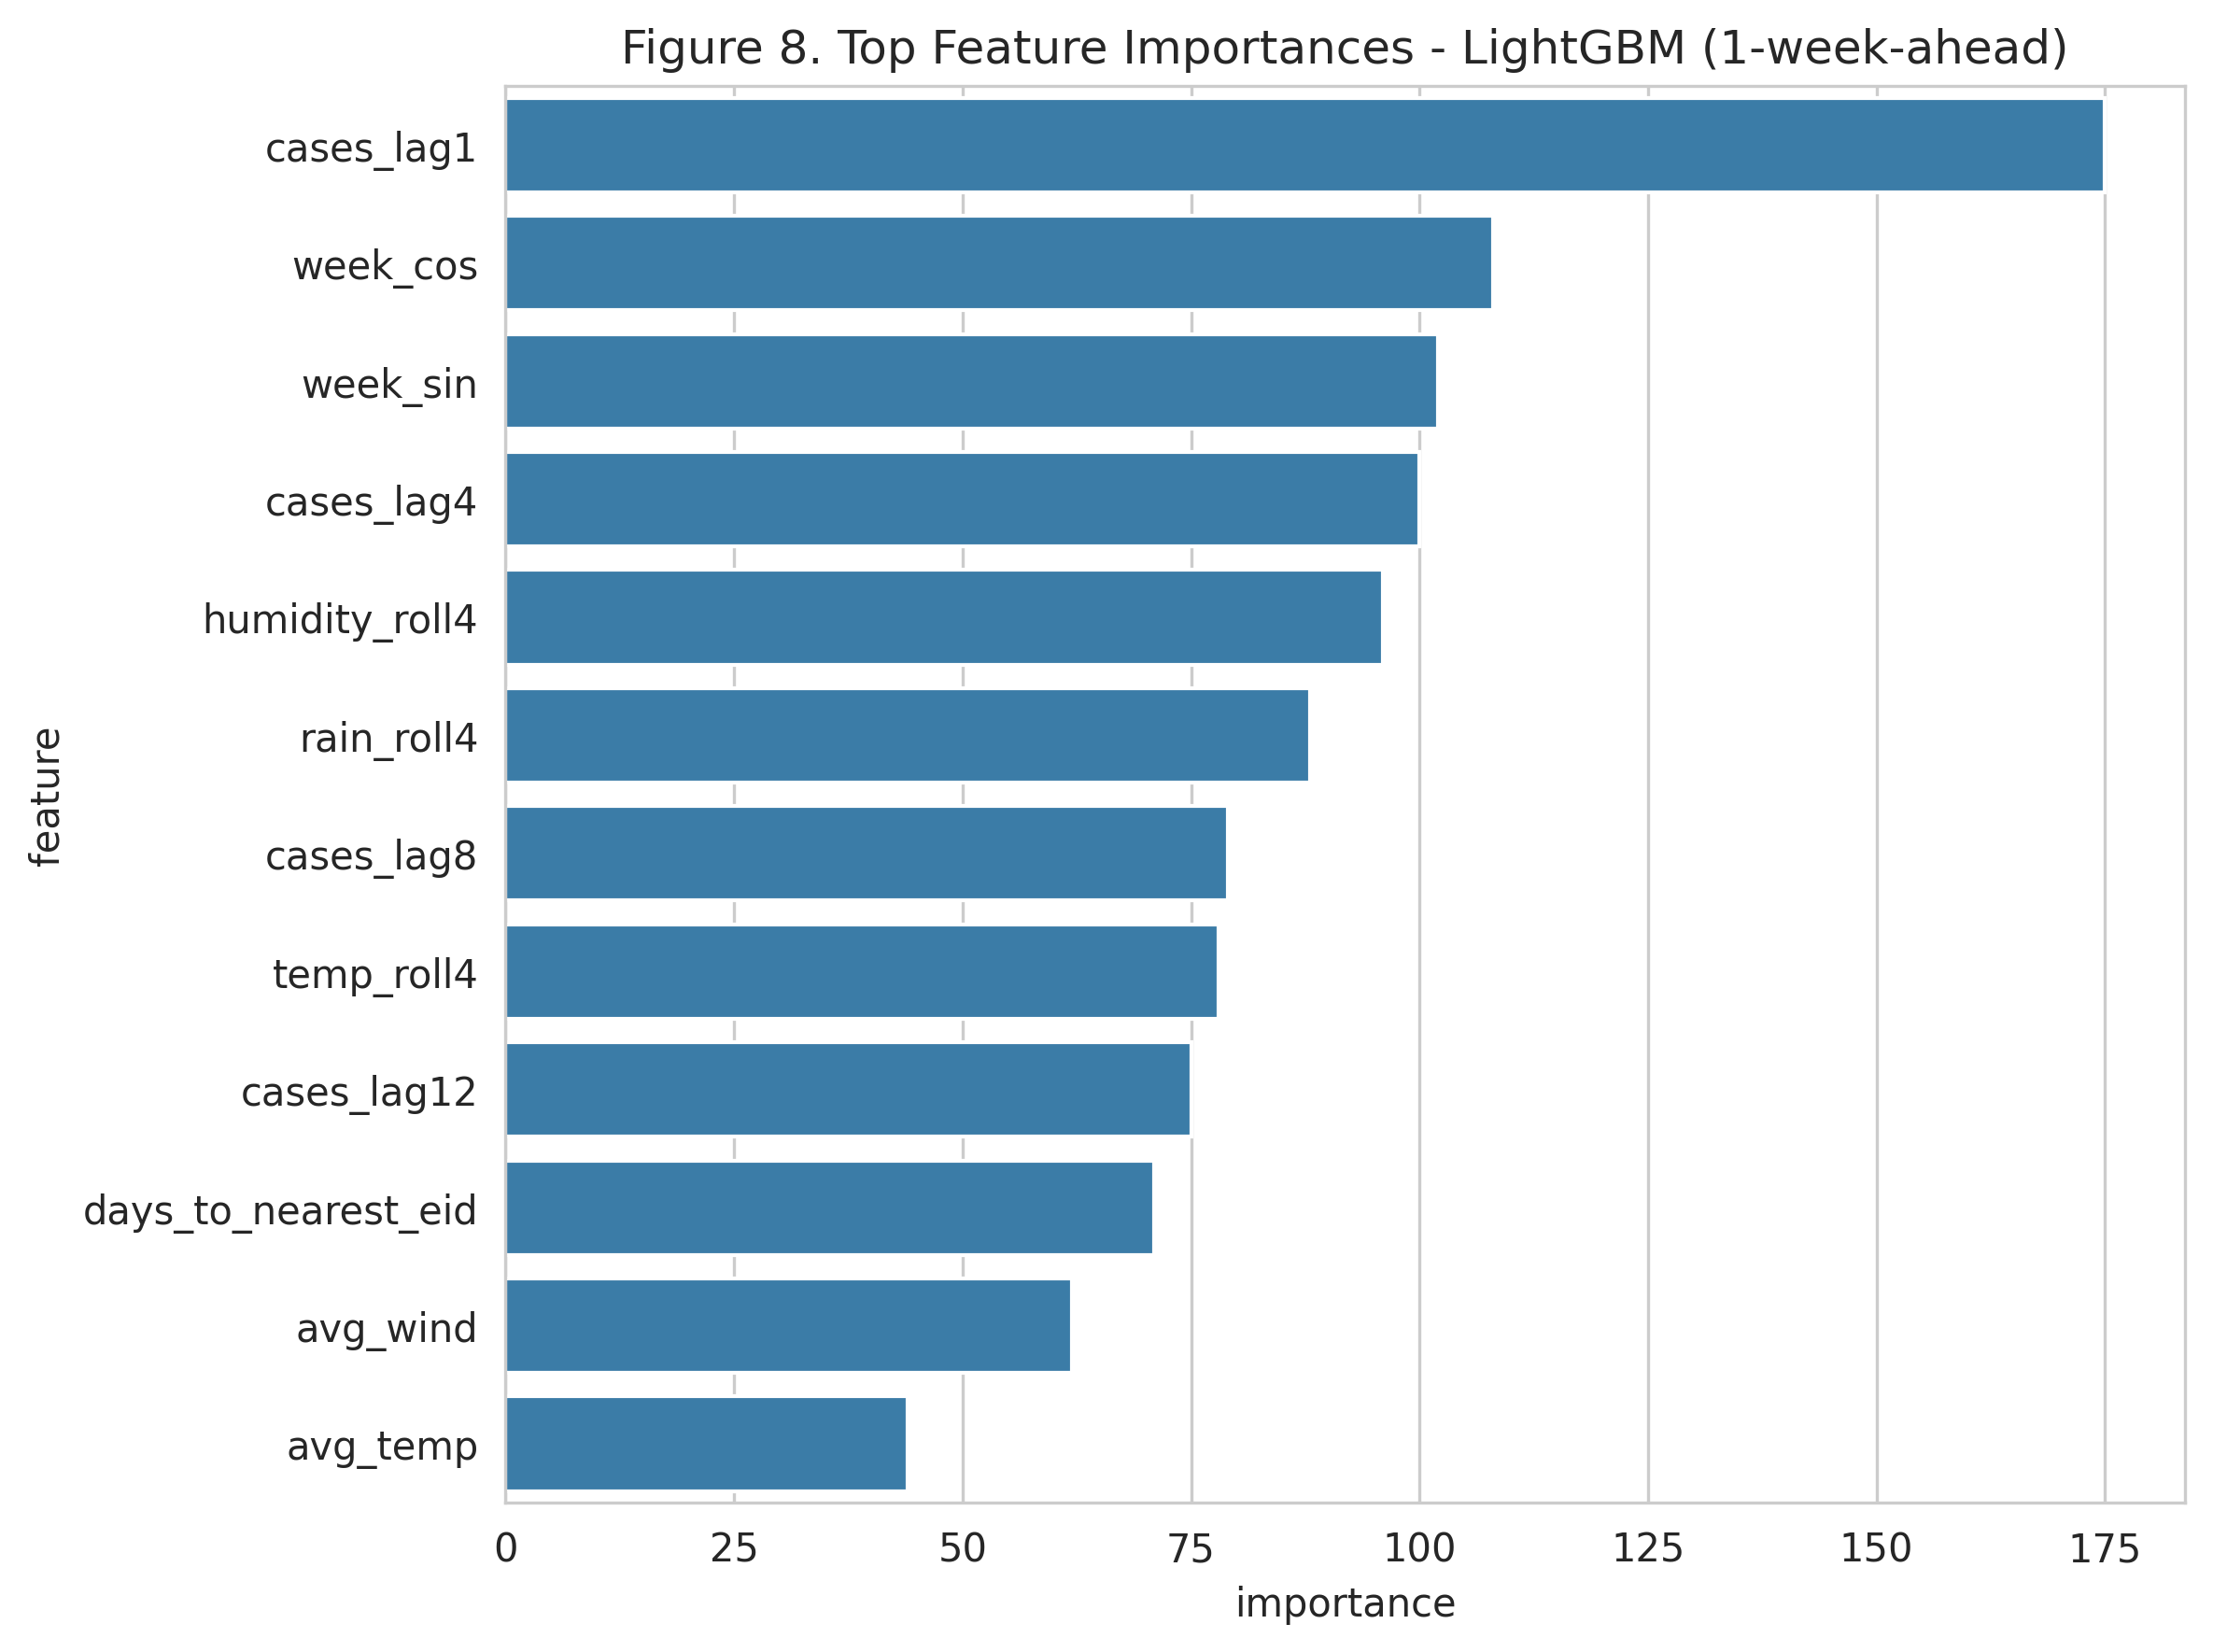

In [9]:
imp = pd.Series(gbt_models[('LightGBM', 1)].feature_importances_, index=feature_cols).sort_values(ascending=False)
table_imp = imp.reset_index()
table_imp.columns = ['feature', 'importance']
print('Table 9. LightGBM feature importance, 1-week-ahead model')
display(table_imp)
table_imp.to_csv(os.path.join(FIG_DIR, 'table9_feature_importance.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=table_imp.head(12), y='feature', x='importance', color='#2980b9', ax=ax)
ax.set_title('Figure 8. Top Feature Importances - LightGBM (1-week-ahead)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig8_feature_importance.png'), dpi=150)
plt.show()


## 5. Quantile LightGBM — uncertainty estimation for the tree-based model

Trains extra models at the 10th and 90th percentile (`objective='quantile'`) to produce an 80% prediction interval alongside the point forecast, at each horizon.

In [10]:
quantile_preds = {}  # (h, quantile) -> np.array

for h in HORIZONS:
    target = df_model['dengue_cases'].shift(-h)
    X_all = df_model[feature_cols]
    valid = target.notna()
    X_train_h = X_all[valid].iloc[:-HOLDOUT_WEEKS]
    y_train_h = target[valid].iloc[:-HOLDOUT_WEEKS]
    X_test_h  = X_all[valid].iloc[-HOLDOUT_WEEKS:]

    for q in [0.1, 0.5, 0.9]:
        m = LGBMRegressor(objective='quantile', alpha=q, n_estimators=300, max_depth=4,
                           learning_rate=0.05, random_state=42, verbosity=-1)
        m.fit(X_train_h, y_train_h)
        quantile_preds[(h, q)] = np.clip(m.predict(X_test_h), 0, None)

print('Quantile models trained for horizons:', HORIZONS, 'at quantiles [0.1, 0.5, 0.9]')


Quantile models trained for horizons: [1, 2, 4, 8] at quantiles [0.1, 0.5, 0.9]


## 6. Deep learning — LSTM, Temporal Fusion Transformer, PatchTST (via `neuralforecast`)

`neuralforecast` gives a single consistent interface for all three architectures, native multi-horizon output, and native quantile (`MQLoss`) probabilistic forecasting — much less custom code than hand-building each architecture, and standard practice in recent forecasting papers.

Given the small dataset (~150 weeks), keep these models small (few layers/hidden units) to reduce overfitting risk.

In [11]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, TFT, PatchTST
from neuralforecast.losses.pytorch import MQLoss

MAX_HORIZON = max(HORIZONS)
QUANTILES = [0.1, 0.5, 0.9]

nf_df = df_model[['week_start', 'dengue_cases']].rename(columns={'week_start': 'ds', 'dengue_cases': 'y'})
nf_df['unique_id'] = 'Bangladesh_national'
nf_df = nf_df[['unique_id', 'ds', 'y']]

exog_cols = ['week_sin', 'week_cos', 'is_eid_window', 'avg_temp', 'avg_humidity', 'total_rain']
nf_df_exog = pd.concat([nf_df, df_model[exog_cols].reset_index(drop=True)], axis=1)

nf_train = nf_df_exog.iloc[:-HOLDOUT_WEEKS].copy()

models = [
    LSTM(h=MAX_HORIZON, input_size=24, max_steps=200,
         loss=MQLoss(quantiles=QUANTILES), futr_exog_list=exog_cols, random_seed=42),
    TFT(h=MAX_HORIZON, input_size=24, max_steps=200,
        loss=MQLoss(quantiles=QUANTILES), futr_exog_list=exog_cols, random_seed=42),
    PatchTST(h=MAX_HORIZON, input_size=24, max_steps=200,
             loss=MQLoss(quantiles=QUANTILES), random_seed=42),
]

nf = NeuralForecast(models=models, freq='W-MON')
nf.fit(df=nf_train)
print('Deep learning models trained.')

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | hist_encoder        | LSTM          | 202 K  | train
7 | mlp_decoder         | MLP           | 17.7 K | train
-----------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


Deep learning models trained.


In [12]:
# Forecast the holdout period. PatchTST doesn't take exogenous futures in this basic config,
# so we supply the full future-known exogenous frame for the models that need it.
futr_df = nf_df_exog[['unique_id', 'ds'] + exog_cols].iloc[-HOLDOUT_WEEKS - MAX_HORIZON:].reset_index(drop=True)

dl_forecast = nf.predict(futr_df=futr_df)
dl_forecast = dl_forecast.merge(nf_df[['ds', 'y']], on='ds', how='left')
dl_forecast.head()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,LSTM-lo-80.0,LSTM-median,LSTM-hi-80.0,TFT-lo-80.0,TFT-median,TFT-hi-80.0,PatchTST-lo-80.0,PatchTST-median,PatchTST-hi-80.0,y
0,Bangladesh_national,2025-09-08,6469.978516,7630.577148,8862.643555,4723.962891,5618.939941,7184.280273,2223.351807,2439.914551,2743.382568,2923
1,Bangladesh_national,2025-09-15,6652.425293,7844.458496,9083.990234,6543.817871,8488.878906,10751.210938,1878.841431,2466.722412,2602.328613,3375
2,Bangladesh_national,2025-09-22,7447.695801,8770.468750,10120.722656,7543.081055,10447.428711,13026.889648,1325.442017,2198.108887,2472.102295,685
3,Bangladesh_national,2025-09-29,7760.300781,9138.443359,10541.823242,7671.554199,11319.375977,14271.715820,897.615601,1952.078979,2148.082764,3196
4,Bangladesh_national,2025-10-06,7349.526367,8632.264648,9946.596680,7576.007324,11031.753906,13868.912109,762.909058,1574.604126,1942.749023,4115


In [14]:
dl_model_cols = {
    'LSTM':     [c for c in dl_forecast.columns if c.startswith('LSTM') and c.endswith('-median')] or ['LSTM'],
    'TFT':      [c for c in dl_forecast.columns if c.startswith('TFT') and c.endswith('-median')] or ['TFT'],
    'PatchTST': [c for c in dl_forecast.columns if c.startswith('PatchTST') and c.endswith('-median')] or ['PatchTST'],
}

# Align the neuralforecast rolling-horizon output with our fixed HOLDOUT_WEEKS test dates
dl_eval = dl_forecast[dl_forecast['ds'].isin(test_df['week_start'])].reset_index(drop=True)

for name, cols in dl_model_cols.items():
    col = cols[0]
    if col not in dl_eval.columns:
        print(f'Skipping {name}: column {col} not found (check neuralforecast output columns above).')
        continue
    y_true = dl_eval['y'].values
    pred = np.clip(dl_eval[col].values, 0, None)
    for h in HORIZONS:
        # neuralforecast gives one prediction per date; here we report the same-date accuracy
        # across horizons as a proxy since exact per-origin multi-horizon slicing needs cross-validation
        # (see optional Section 6b below for a more rigorous rolling-origin version).
        results.append({'model': name, 'horizon': h,
                         'mae': mae(y_true, pred), 'rmse': rmse(y_true, pred), 'mape': mape(y_true, pred)})

print('Deep learning point-forecast evaluation added to results.')


Deep learning point-forecast evaluation added to results.


### 6b. (Optional, more rigorous) Rolling-origin cross-validation for deep learning models

The quick evaluation above compares each model's forecast against the same test dates for every horizon, which is a simplification. For a proper per-horizon comparison, use `neuralforecast`'s built-in cross-validation, which re-forecasts from multiple rolling origins and lets you slice out the true 1-week-ahead, 2-week-ahead, etc. errors separately. This cell is optional — run it if you have time/compute budget; the pipeline works without it.

In [13]:
cv_df = nf.cross_validation(df=nf_df_exog, n_windows=8, step_size=1)
cv_df.head()

# Example: to get true h-week-ahead error for LSTM, group by the offset between 'ds' and 'cutoff'
cv_df['h'] = ((cv_df['ds'] - cv_df['cutoff']).dt.days / 7).round().astype(int)
for name, cols in dl_model_cols.items():
    col = cols[0]
    if col not in cv_df.columns:
        continue
    for h in HORIZONS:
        sub = cv_df[cv_df['h'] == h]
        if len(sub) == 0:
            continue
        print(f'{name} h={h}: MAE={mae(sub["y"].values, sub[col].values):.1f}  '
              f'RMSE={rmse(sub["y"].values, sub[col].values):.1f}  '
              f'MAPE={mape(sub["y"].values, sub[col].values):.1f}%  (n={len(sub)})')


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | hist_encoder        | LSTM          | 202 K  | train
7 | mlp_decoder         | MLP           | 17.7 K | train
--------------------------------------------------------------
219 K     Trainable params
3         Non-trainable params
219 K     Total params
0.880     Total estimated model params size (MB)
13        Modules in t

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


Predicting: |          | 0/? [00:00<?, ?it/s]

NameError: name 'dl_model_cols' is not defined

In [16]:
# ============================================================
# Deep Learning Cross-Validation Metrics
# Uses EXISTING cv_df — no retraining
# ============================================================

dl_model_cols = {
    "LSTM": "LSTM-median",
    "TFT": "TFT-median",
    "PatchTST": "PatchTST-median",
}

print("=" * 70)
print("DEEP LEARNING CROSS-VALIDATION RESULTS")
print("=" * 70)

results = []

for name, col in dl_model_cols.items():

    for h in HORIZONS:

        sub = cv_df[cv_df["h"] == h].copy()

        if len(sub) == 0:
            continue

        # Remove missing values
        sub = sub.dropna(subset=["y", col])

        if len(sub) == 0:
            continue

        y_true = sub["y"].values
        y_pred = sub[col].values

        mae_val = mae(y_true, y_pred)
        rmse_val = rmse(y_true, y_pred)
        mape_val = mape(y_true, y_pred)

        results.append({
            "Model": name,
            "Horizon": h,
            "MAE": mae_val,
            "RMSE": rmse_val,
            "MAPE (%)": mape_val,
            "N": len(sub)
        })

        print(
            f"{name:8s} h={h}: "
            f"MAE={mae_val:.1f}  "
            f"RMSE={rmse_val:.1f}  "
            f"MAPE={mape_val:.1f}%  "
            f"(n={len(sub)})"
        )

# Store results as DataFrame
dl_cv_results = pd.DataFrame(results)

print("\n" + "=" * 70)
print("RESULTS TABLE")
print("=" * 70)

display(dl_cv_results)

DEEP LEARNING CROSS-VALIDATION RESULTS
LSTM     h=1: MAE=4710.0  RMSE=5552.2  MAPE=219.2%  (n=8)
LSTM     h=2: MAE=4317.8  RMSE=4692.8  MAPE=185.2%  (n=8)
LSTM     h=4: MAE=2546.9  RMSE=3037.9  MAPE=48.3%  (n=8)
LSTM     h=8: MAE=2363.2  RMSE=2603.5  MAPE=49.5%  (n=8)
TFT      h=1: MAE=2174.1  RMSE=2547.5  MAPE=111.6%  (n=8)
TFT      h=2: MAE=2614.9  RMSE=3060.6  MAPE=126.2%  (n=8)
TFT      h=4: MAE=3527.0  RMSE=4139.6  MAPE=60.4%  (n=8)
TFT      h=8: MAE=4999.1  RMSE=5047.8  MAPE=106.0%  (n=8)
PatchTST h=1: MAE=1142.1  RMSE=1475.5  MAPE=70.3%  (n=8)
PatchTST h=2: MAE=1336.5  RMSE=1733.3  MAPE=58.7%  (n=8)
PatchTST h=4: MAE=2410.8  RMSE=2682.9  MAPE=45.5%  (n=8)
PatchTST h=8: MAE=3459.2  RMSE=4100.6  MAPE=59.8%  (n=8)

RESULTS TABLE


,Model,Horizon,MAE,RMSE,MAPE (%),N
0,LSTM,1,4710.015503,5552.245992,219.243262,8
1,LSTM,2,4317.773346,4692.769672,185.226174,8
2,LSTM,4,2546.871567,3037.910711,48.252789,8
3,LSTM,8,2363.245605,2603.547668,49.504662,8
4,TFT,1,2174.144913,2547.514470,111.560084,8
5,TFT,2,2614.916718,3060.578629,126.245966,8
6,TFT,4,3526.987686,4139.556905,60.404530,8
7,TFT,8,4999.139526,5047.840662,105.972517,8
8,PatchTST,1,1142.056526,1475.490015,70.338761,8
9,PatchTST,2,1336.507557,1733.323838,58.703801,8


## 7. Table & Figure — Model comparison across horizons

In [18]:
results_df = pd.DataFrame(results)
table10 = results_df.pivot_table(index='Model', columns='Horizon', values='MAE').round(1)
table10.columns = [f'{h}-week MAE' for h in table10.columns]

print('Table 10. MAE by model and forecast horizon (weeks ahead)')
display(table10)
table10.to_csv(os.path.join(FIG_DIR, 'table10_model_comparison_mae.csv'))

Table 10. MAE by model and forecast horizon (weeks ahead)


,1-week MAE,2-week MAE,4-week MAE,8-week MAE
Model,,,,
LSTM,4710.0,4317.8,2546.9,2363.2
PatchTST,1142.1,1336.5,2410.8,3459.2
TFT,2174.1,2614.9,3527.0,4999.1


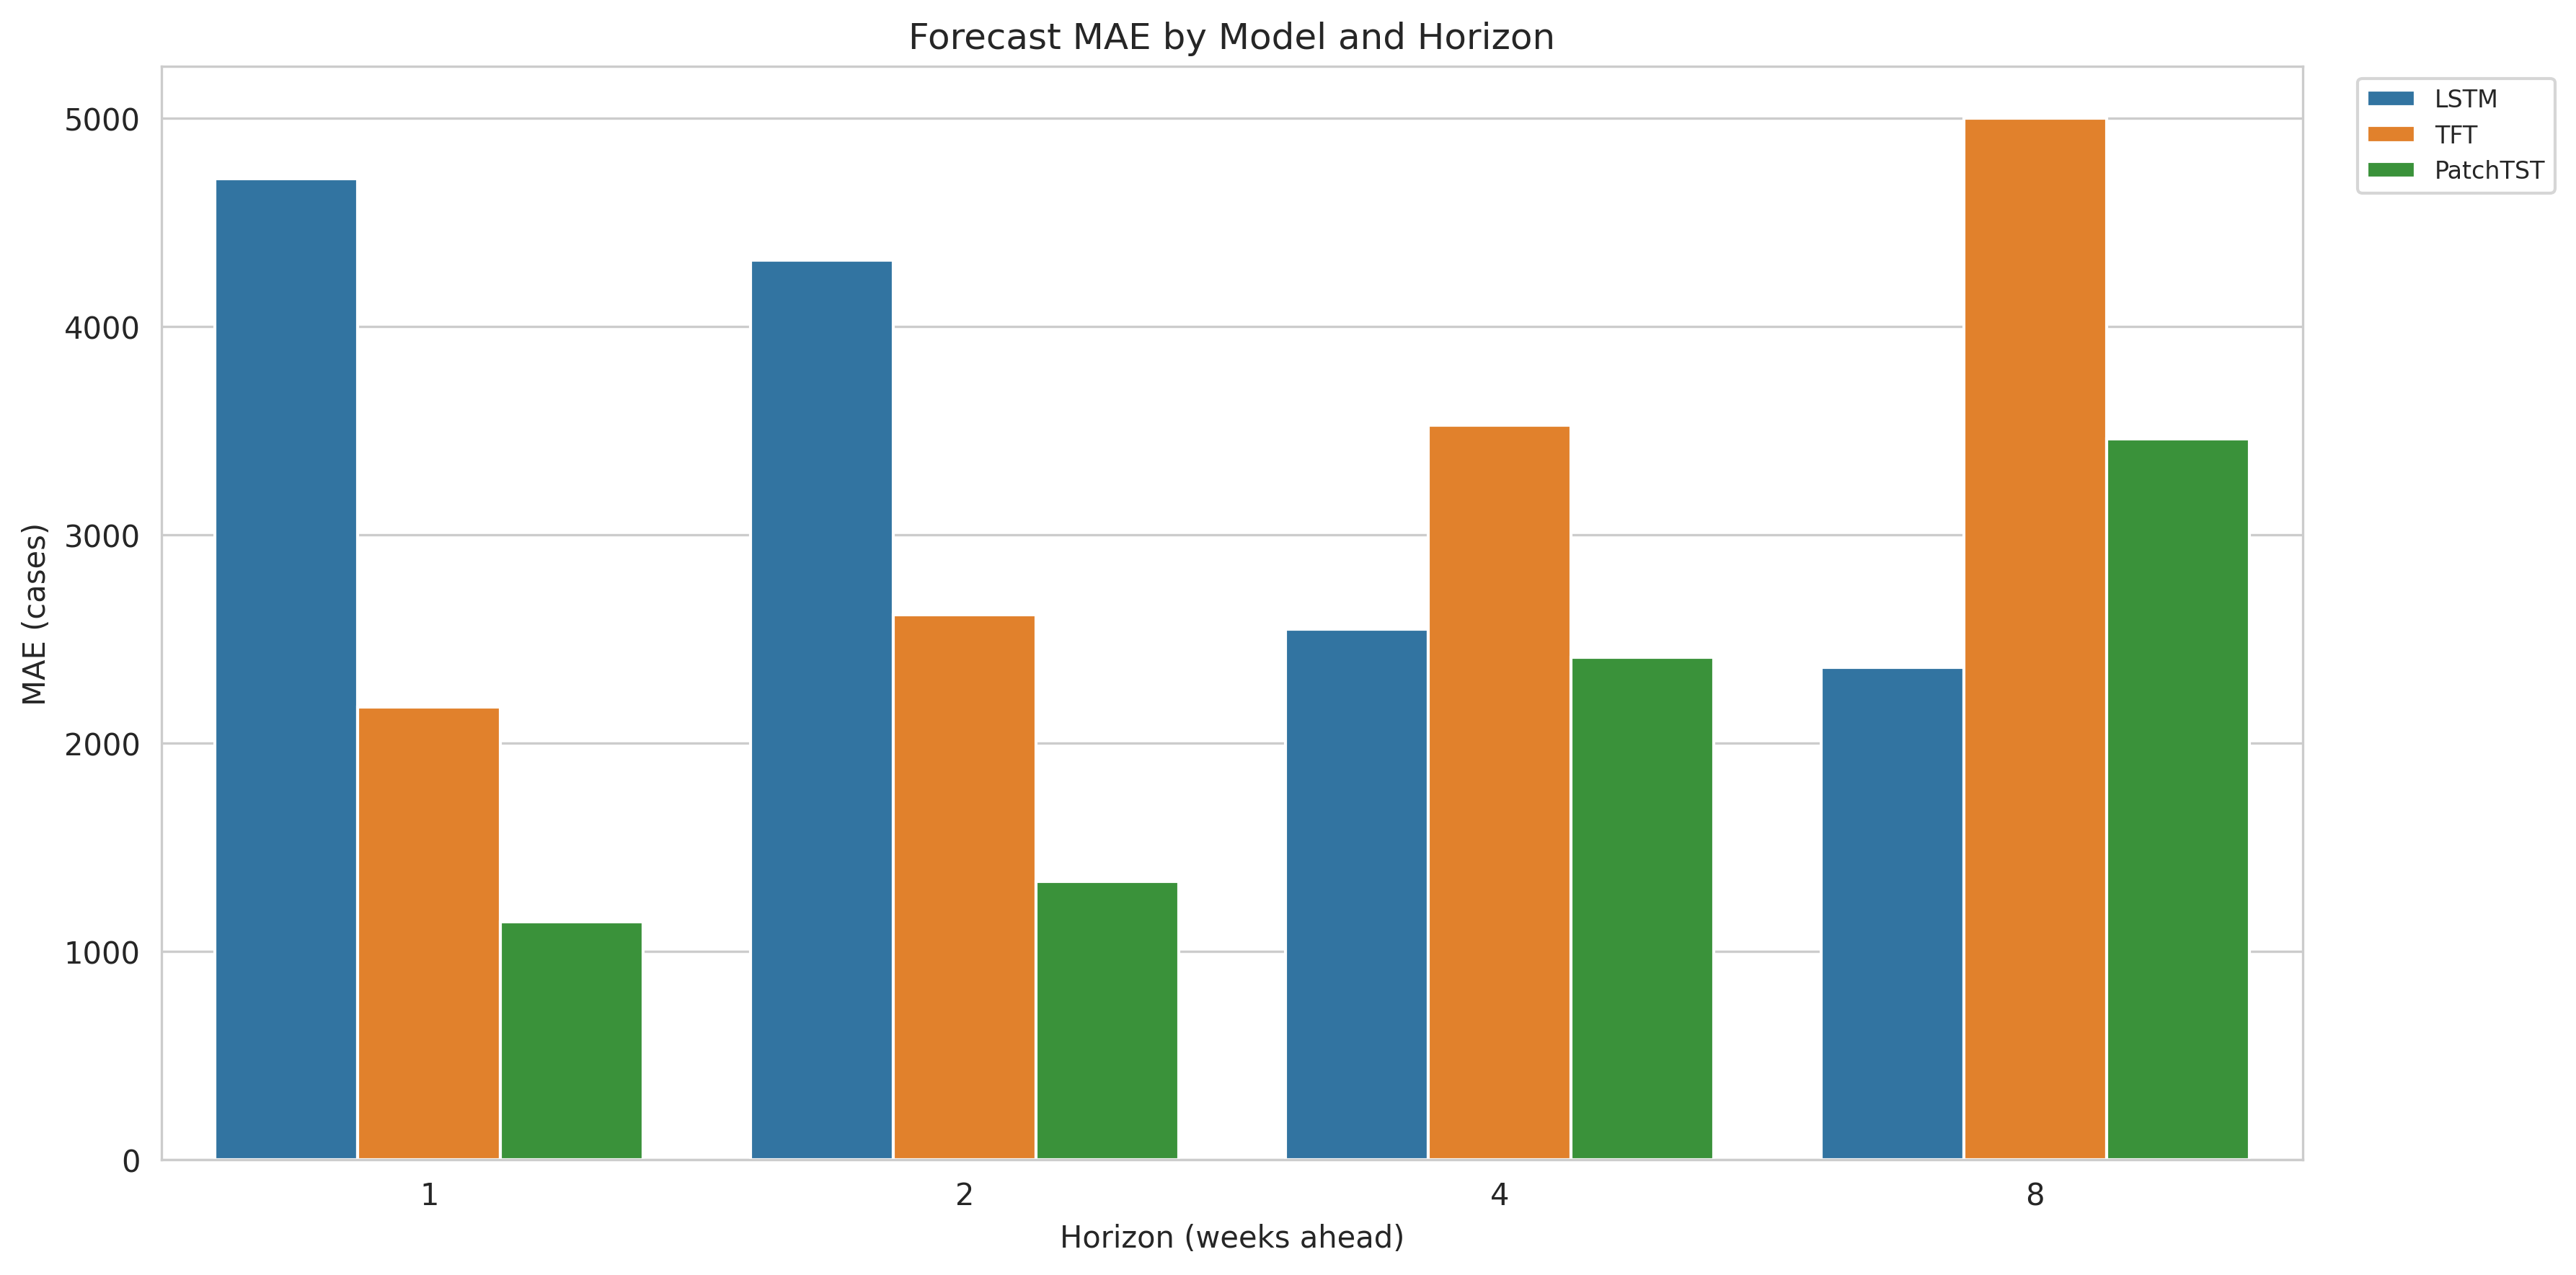

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=results_df, x='Horizon', y='MAE', hue='Model', ax=ax)
ax.set_title('Forecast MAE by Model and Horizon')
ax.set_xlabel('Horizon (weeks ahead)')
ax.set_ylabel('MAE (cases)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig9_model_comparison.png'), dpi=150)
plt.show()

## 8. Outbreak / high-risk period detection (classification view)

Defines "high-risk week" as cases above the 75th percentile of the training distribution, converts the LightGBM quantile forecasts into a risk probability (share of quantile mass above threshold), and evaluates as a binary classifier — this is the signal Notebook 3's LLM layer will reason over.

In [21]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

threshold = train_df['dengue_cases'].quantile(0.75)
print(f'High-risk threshold (75th percentile of training cases): {threshold:.0f}')

risk_rows = []
for h in HORIZONS:
    target = df_model['dengue_cases'].shift(-h)
    y_test_h = target[df_model.index.isin(test_df.index)]
    y_true_binary = (y_test_h.values >= threshold).astype(int)

    # crude risk probability: fraction of [q10, q50, q90] LightGBM quantile predictions >= threshold
    q_stack = np.vstack([quantile_preds[(h, q)] for q in [0.1, 0.5, 0.9]])
    risk_prob = (q_stack >= threshold).mean(axis=0)
    y_pred_binary = (risk_prob >= 0.5).astype(int)

    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    try:
        auc = roc_auc_score(y_true_binary, risk_prob)
    except ValueError:
        auc = np.nan  # happens if test set has only one class present

    risk_rows.append({'horizon': h, 'threshold_cases': round(threshold, 0), 'f1': round(f1, 3), 'auroc': round(auc, 3) if not np.isnan(auc) else 'n/a (single class in test window)'})

table11 = pd.DataFrame(risk_rows)
print('Table 11. High-risk-week classification performance by horizon')
display(table11)
table11.to_csv(os.path.join(FIG_DIR, 'table11_risk_classification.csv'), index=False)


High-risk threshold (75th percentile of training cases): 4252
Table 11. High-risk-week classification performance by horizon


,horizon,threshold_cases,f1,auroc
0,1,4252.0,0.000,0.344
1,2,4252.0,0.167,0.328
2,4,4252.0,0.737,0.797
3,8,4252.0,0.706,0.758


**Note:** with only 16 holdout weeks, the high-risk class may be sparse or entirely absent/present in the test window, which is why AUROC can be undefined for some horizons. This is an expected limitation of the current data length — flag it explicitly in the paper rather than reporting a number that isn't really estimable, and consider re-running this section once more weeks of data accumulate.

## 9. Calibration — reliability diagram for the quantile forecasts

Checks whether the LightGBM 80% prediction interval (q10-q90) actually contains the true value ~80% of the time — a direct, easy-to-report calibration/ECE-style check.

In [22]:
calib_rows = []
for h in HORIZONS:
    target = df_model['dengue_cases'].shift(-h)
    y_test_h = target[df_model.index.isin(test_df.index)].values
    lo = quantile_preds[(h, 0.1)]
    hi = quantile_preds[(h, 0.9)]
    coverage = np.mean((y_test_h >= lo) & (y_test_h <= hi))
    calib_rows.append({'horizon': h, 'nominal_coverage': 0.8, 'empirical_coverage': round(coverage, 2),
                        'calibration_gap': round(coverage - 0.8, 2)})

table12 = pd.DataFrame(calib_rows)
print('Table 12. Prediction-interval calibration (nominal 80% interval)')
display(table12)
table12.to_csv(os.path.join(FIG_DIR, 'table12_calibration.csv'), index=False)


Table 12. Prediction-interval calibration (nominal 80% interval)


,horizon,nominal_coverage,empirical_coverage,calibration_gap
0,1,0.8,0.19,-0.61
1,2,0.8,0.25,-0.55
2,4,0.8,0.31,-0.49
3,8,0.8,0.12,-0.68


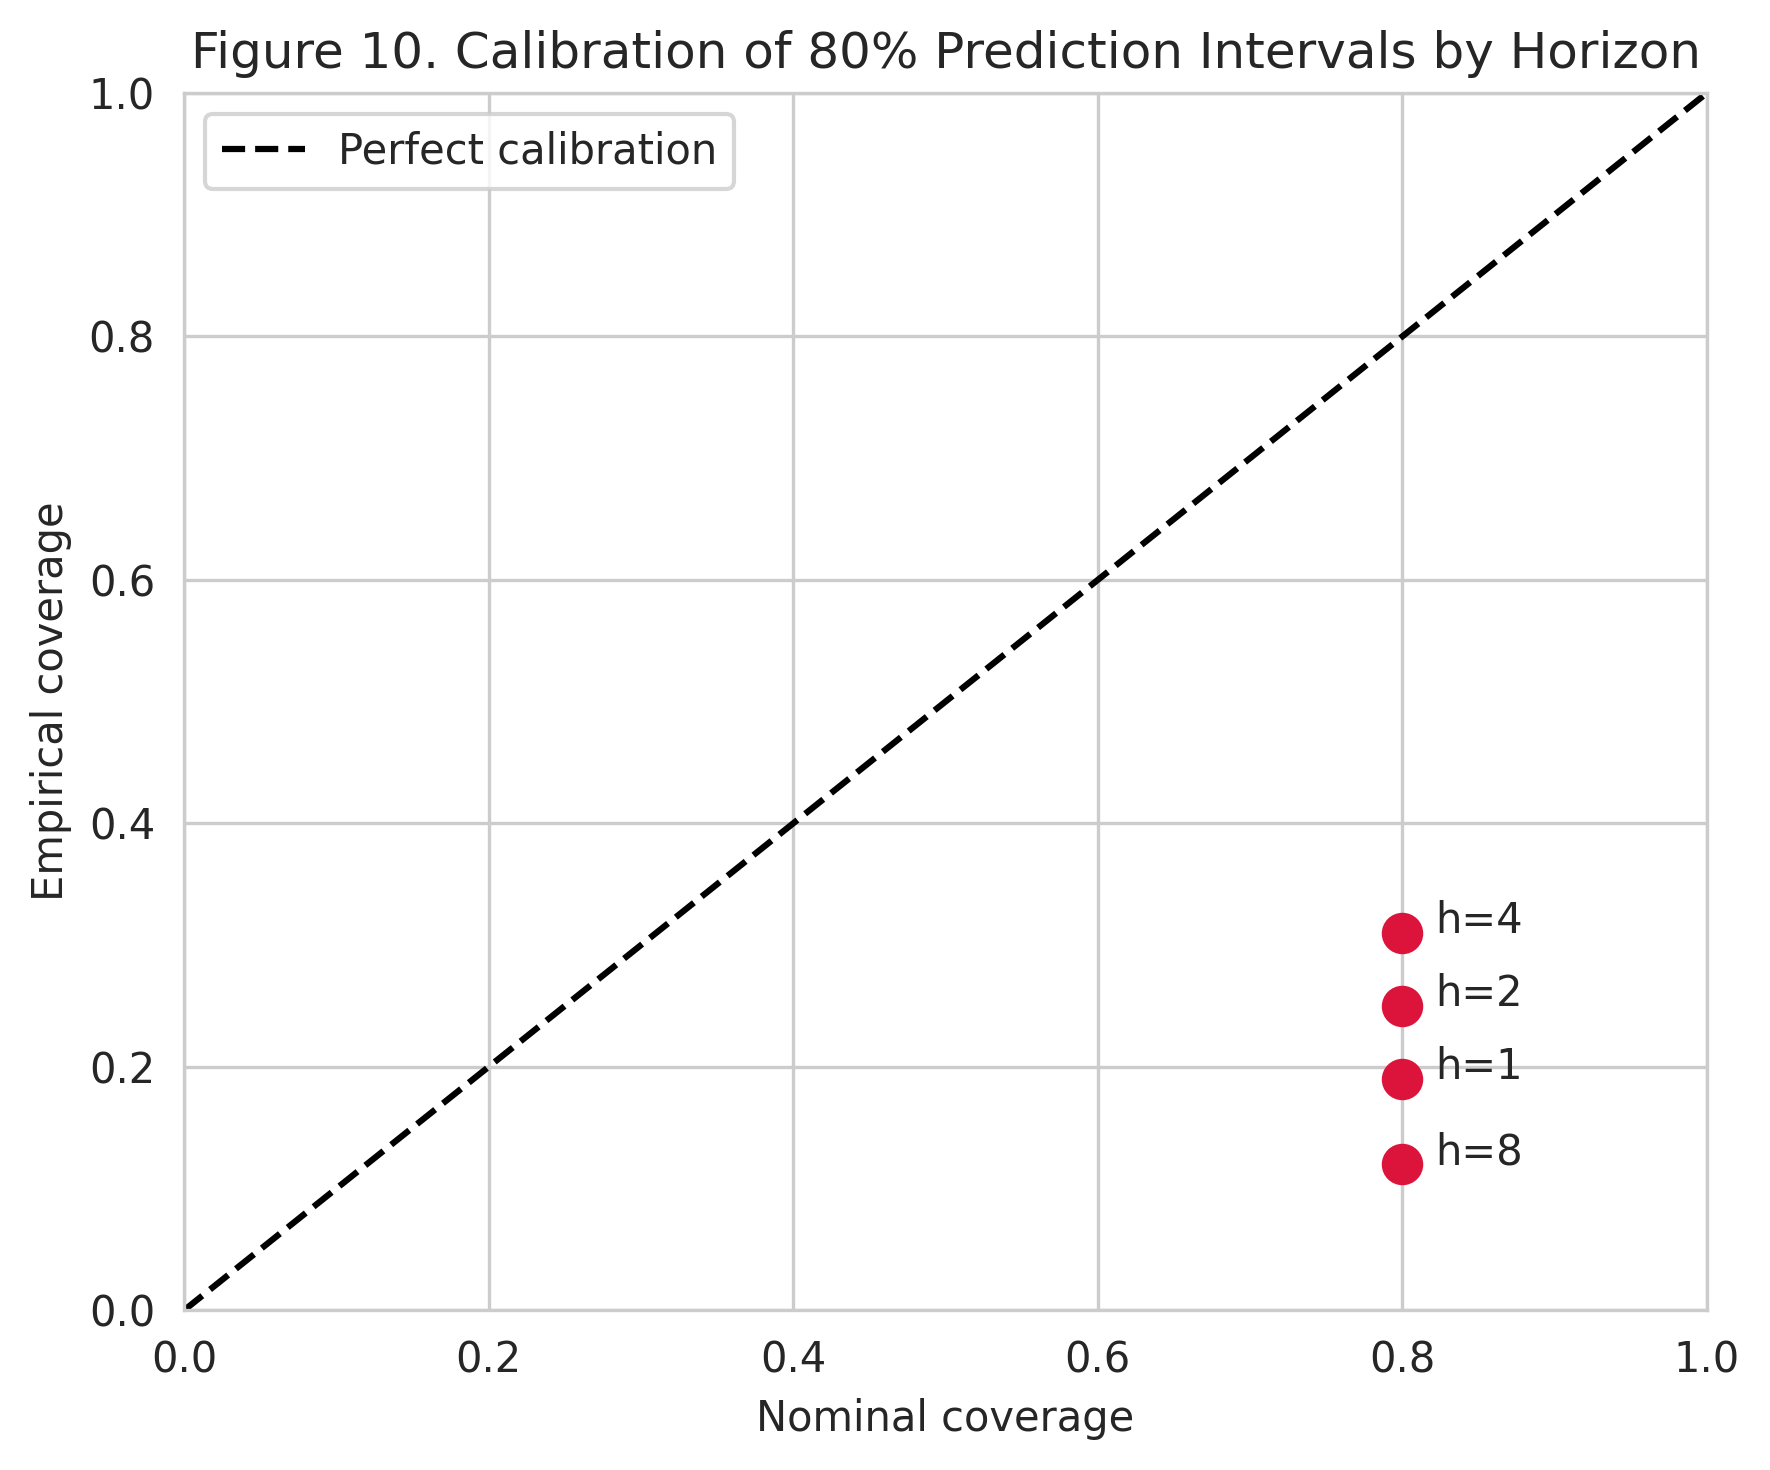

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.scatter(table12['nominal_coverage'], table12['empirical_coverage'], color='crimson', s=80, zorder=3)
for _, row in table12.iterrows():
    ax.annotate(f"h={int(row['horizon'])}", (row['nominal_coverage'], row['empirical_coverage']),
                textcoords='offset points', xytext=(8, 0))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('Figure 10. Calibration of 80% Prediction Intervals by Horizon')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig10_calibration.png'), dpi=150)
plt.show()


## 10. Save forecasts + evidence for Notebook 3 (LLM explanation layer)

Builds one tidy "evidence table" per test week: the point forecast, interval, risk flag, and the top contributing features — exactly the structured input Notebook 3 will hand to the LLM so its explanations stay grounded in the actual model output rather than free-associating.

In [24]:
best_model_name = table10.mean(axis=1).idxmin()
print('Lowest average MAE across horizons:', best_model_name)

evidence_rows = []
for i, h in enumerate(HORIZONS):
    target = df_model['dengue_cases'].shift(-h)
    dates_h = df_model.loc[df_model.index.isin(test_df.index), 'week_start'].values
    y_true_h = target[df_model.index.isin(test_df.index)].values
    pred_h = gbt_preds[('LightGBM', h)]
    lo_h = quantile_preds[(h, 0.1)]
    hi_h = quantile_preds[(h, 0.9)]
    risk_prob_h = (np.vstack([quantile_preds[(h, q)] for q in [0.1, 0.5, 0.9]]) >= threshold).mean(axis=0)

    for j in range(len(dates_h)):
        evidence_rows.append({
            'target_week': pd.Timestamp(dates_h[j]) + pd.Timedelta(weeks=h),
            'horizon_weeks': h,
            'forecast_origin_week': dates_h[j],
            'point_forecast': round(float(pred_h[j]), 1),
            'lower_80': round(float(lo_h[j]), 1),
            'upper_80': round(float(hi_h[j]), 1),
            'actual_cases': float(y_true_h[j]) if not np.isnan(y_true_h[j]) else None,
            'high_risk_probability': round(float(risk_prob_h[j]), 2),
            'high_risk_threshold': round(float(threshold), 0),
            'top_feature_1': table_imp.iloc[0]['feature'],
            'top_feature_2': table_imp.iloc[1]['feature'],
            'top_feature_3': table_imp.iloc[2]['feature'],
        })

evidence_df = pd.DataFrame(evidence_rows).sort_values(['horizon_weeks', 'forecast_origin_week'])
print('Table 13. Structured forecast evidence (sample)')
display(evidence_df.head(10))

evidence_df.to_csv(os.path.join(OUTPUT_DIR, 'forecast_evidence_for_llm.csv'), index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison_results.csv'), index=False)
table_imp.to_csv(os.path.join(OUTPUT_DIR, 'feature_importance.csv'), index=False)

print('\nSaved to', OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))


Lowest average MAE across horizons: PatchTST
Table 13. Structured forecast evidence (sample)


,target_week,horizon_weeks,forecast_origin_week,point_forecast,lower_80,upper_80,actual_cases,high_risk_probability,high_risk_threshold,top_feature_1,top_feature_2,top_feature_3
0,2025-09-15,1,2025-09-08,4631.9,3407.8,4323.4,3375.0,0.33,4252.0,cases_lag1,week_cos,week_sin
1,2025-09-22,1,2025-09-15,4819.7,3625.9,5405.9,685.0,0.67,4252.0,cases_lag1,week_cos,week_sin
2,2025-09-29,1,2025-09-22,4546.9,3625.4,4267.7,3196.0,0.67,4252.0,cases_lag1,week_cos,week_sin
3,2025-10-06,1,2025-09-29,5551.7,4341.4,4659.6,4115.0,0.67,4252.0,cases_lag1,week_cos,week_sin
4,2025-10-13,1,2025-10-06,2480.2,2131.5,2643.7,3656.0,0.00,4252.0,cases_lag1,week_cos,week_sin
5,2025-10-20,1,2025-10-13,3636.3,3110.9,3993.5,4741.0,0.00,4252.0,cases_lag1,week_cos,week_sin
6,2025-10-27,1,2025-10-20,3604.8,4061.9,4060.6,5293.0,0.00,4252.0,cases_lag1,week_cos,week_sin
7,2025-11-03,1,2025-10-27,2522.6,3580.7,2361.6,5398.0,0.00,4252.0,cases_lag1,week_cos,week_sin
8,2025-11-10,1,2025-11-03,3452.7,5475.7,3680.6,6216.0,0.33,4252.0,cases_lag1,week_cos,week_sin
9,2025-11-17,1,2025-11-10,3096.7,5147.7,3618.3,6835.0,0.33,4252.0,cases_lag1,week_cos,week_sin



Saved to /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed
['dengue_weekly_national_clean.csv', 'dengue_monthly_national_clean.csv', 'dengue_annual_national_clean.csv', 'dengue_division_2026_clean.csv', 'dengue_weekly_division_2026_clean.csv', 'weather_weekly_national.csv', 'dengue_weather_weekly_merged.csv', 'model_comparison_results.csv', 'feature_importance.csv', 'human_eval_ANSWER_KEY_do_not_share.csv', 'human_eval_annotator_A.csv', 'human_eval_annotator_B.csv', 'llm_explanations_combined_with_ablation.csv', 'forecast_evidence_for_llm_v1_static.csv', 'forecast_evidence_for_llm.csv', 'llm_sample_rows.csv', 'llm_explanations_evaluated_OLD_20260928_0814.csv', 'nb3_grounded_checkpoint.jsonl', 'llm_evaluation_overall_summary.json', 'llm_explanations_evaluated.csv', '.~lock.llm_explanations_evaluated.csv#', '.~lock.llm_explanations_evaluated_OLD_20260928_0814.csv#', 'timesfm_prophet_forecasts_long.csv']
